# 2f. Calculate closed- and open-system degassing paths including isotopic fractionation

These examples include isotopic fractionation of C, H, and S during closed- and open-system degassing.

## Python set-up
You need to install VolFe once on your machine, if you haven't yet. Then we need to import a few Python packages (including VolFe). 

In [22]:
# Install VolFe on your machine. Don't remove the # from this line!
# pip install VolFe # Remove the first # in this line if you have not installed VolFe on your machine before.

# import python packages
import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf
import numpy as np

In [2]:
# VolFe version
vf.__version__

'1.0'

## Define the inputs

The following composition is analysis Sari15-04-33 from Brounce et al. (2014) with the updated Fe<sup>3+</sup>/Fe<sub>T</sub> from Cottrell et al. (2021), with a temperature chosen as 1200 °C.

In [3]:
# Define the melt composition, fO2 estimate, and T as a dictionary.
my_analysis = {'Sample':'Sari15-04-33',
           'T_C': 1200., # Temperature in 'C
           'SiO2': 47.89, # wt%
           'TiO2': 0.75, # wt%
           'Al2O3': 16.74, # wt%
           'FeOT': 9.43, # wt%
           'MnO': 0.18, # wt%
           'MgO': 5.92, # wt%
           'CaO': 11.58, # wt%
           'Na2O': 2.14, # wt%
           'K2O': 0.63, # wt%
           'P2O5': 0.17, # wt%
           'H2O': 4.17, # wt%
           'CO2ppm': 1487., # ppm
           'STppm': 1343.5, # ppm
           'Xppm': 0., # ppm
           'Fe3FeT': 0.177}

# Turn the dictionary into a pandas dataframe, setting the index to 0.
my_analysis = pd.DataFrame(my_analysis, index=[0])

## Run the concentration and speciation calculation

### Closed-system

In [5]:
degas_closed = vf.calc_gassing(my_analysis)

 98%|█████████▊| 3799.0/3863 [00:24<00:00, 153.72it/s]


### Open-system

In [6]:
# choose the options I want - everything else will use the default options
my_models = [['gassing_style','open']]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

In [7]:
degas_open = vf.calc_gassing(my_analysis, models=my_models)

 62%|██████▏   | 2406.0/3863 [22:26<13:35,  1.79it/s]  


## Run the isotope calculation

We use the outputs of the concentration and speciation calculation as inputs to the isotope calculation, specifying the initial isotopic ratio of H, C, and S in delta notation. We will use the default isotopic fractionation factors.

### Define initial isotopic composition

In [8]:
# initial isotope composition
R_i = {"d34S":0,'d13C':0.,'dD':0.}

### Closed-system

In [10]:
# makes dataframe output from degassing calcualtion into input for isotope calculation
comp1 = degas_closed.reset_index(drop=True) # resets the index
comp1 = comp1[1:] # gets rid of the result at pvsat - isotopes need both melt and vapor to be present at the moment so it doens't work at pvsat currently
comp2 = comp1.reset_index(drop=True) # resets the index again

# runs the isotope calculation
iso_closed = vf.calc_isotopes_gassing(comp2,R_i)

### Open-system

In [11]:
# makes dataframe output from degassing calcualtion into input for isotope calculation
comp1 = degas_open.reset_index(drop=True) # resets the index
comp1 = comp1[1:] # gets rid of the result at pvsat - isotopes need both melt and vapor to be present at the moment so it doens't work at pvsat currently
comp2 = comp1.reset_index(drop=True) # resets the index again

# runs the isotope calculation
iso_open = vf.calc_isotopes_gassing(comp2,R_i,models=my_models)

## Plotting

Here we show the bulk melt (red) and gas (blue) isotopic compositions during closed- (solid) and open- (dashed) system degassing

(4000.0, 0.0)

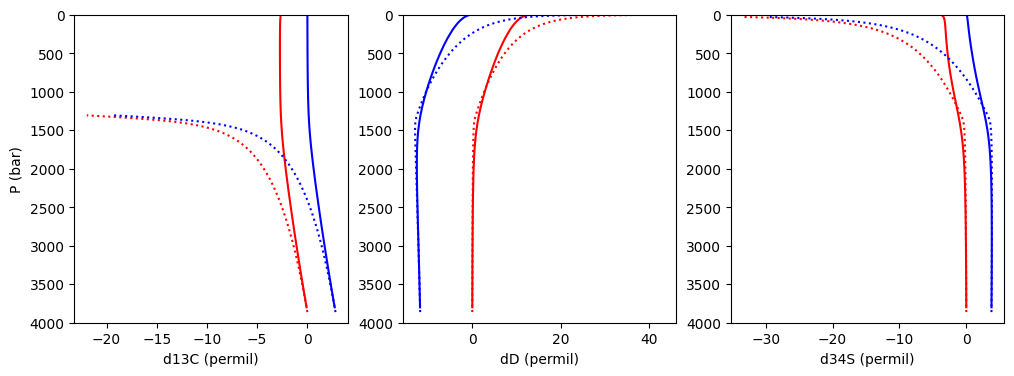

In [68]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

data1 = iso_closed # closed-system degassing
data2 = iso_open # open-system degassing

# Plotting results
ax1.plot(data1['d13C_m_tot'], data1['P_bar'], '-r')
ax1.plot(data2.loc[0:1130,'d13C_m_tot'], data2.loc[0:1130,'P_bar'], ':r')
ax1.plot(data1['d13C_g_tot'], data1['P_bar'], '-b')
ax1.plot(data2.loc[0:1130,'d13C_g_tot'], data2.loc[0:1130,'P_bar'], ':b')
ax2.plot(data1['dD_m_tot'], data1['P_bar'], '-r')
ax2.plot(data2['dD_m_tot'], data2['P_bar'], ':r')
ax2.plot(data1['dD_g_tot'], data1['P_bar'], '-b')
ax2.plot(data2['dD_g_tot'], data2['P_bar'], ':b')
ax3.plot(data1['d34S_m_tot'], data1['P_bar'], '-r')
ax3.plot(data2.loc[0:2378,'d34S_m_tot'], data2.loc[0:2378,'P_bar'], ':r')
ax3.plot(data1['d34S_g_tot'], data1['P_bar'], '-b')
ax3.plot(data2.loc[0:2378,'d34S_g_tot'], data2.loc[0:2378,'P_bar'], ':b')

ax1.set_ylabel('P (bar)')
ax1.set_xlabel('d13C (permil)')
ax2.set_xlabel('dD (permil)')
ax3.set_xlabel('d34S (permil)')
ax1.set_ylim([4000,0])
ax2.set_ylim([4000,0])
ax3.set_ylim([4000,0])